In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

input_file='etup_mensual_tr_cifra_1986_2026.csv'
df = pd.read_csv(input_file, on_bad_lines='skip')

df['VALOR'] = pd.to_numeric(df['VALOR'], errors='coerce')
df = df.dropna(subset=['VALOR'])

print(f"Data Loaded: {len(df)} rows")

df.head(15)

Data Loaded: 32275 rows


,ANIO,ID_MES,TRANSPORTE,VARIABLE,CVEGEO,CVE_ENT,CVE_MUN,VALOR,ESTATUS
0,1986,1,Red de Transporte de Pasajeros,Autobuses en operación de lunes a viernes,9999,9,999,4201.0,Cifras Definitivas
1,1986,1,Red de Transporte de Pasajeros,Autobuses en operación de sábado a domingo,9999,9,999,2601.0,Cifras Definitivas
2,1986,1,Red de Transporte de Pasajeros,Kilómetros recorridos,9999,9,999,27199400.0,Cifras Definitivas
3,1986,1,Red de Transporte de Pasajeros,Pasajeros transportados,9999,9,999,172000400.0,Cifras Definitivas
4,1986,1,Red de Transporte de Pasajeros,Personal ocupado,9999,9,999,22451.0,Cifras Definitivas
5,1986,1,Red de Transporte de Pasajeros,Rutas,9999,9,999,219.0,Cifras Definitivas
6,1986,1,Sistema de Transporte Colectivo Metro,Energía eléctrica consumida,9999,9,999,60786000.0,Cifras Definitivas
7,1986,1,Sistema de Transporte Colectivo Metro,Kilómetros recorridos,9999,9,999,2126600.0,Cifras Definitivas
8,1986,1,Sistema de Transporte Colectivo Metro,Longitud de servicio,9999,9,999,115.0,Cifras Definitivas
9,1986,1,Sistema de Transporte Colectivo Metro,Pasajeros transportados,9999,9,999,110245300.0,Cifras Definitivas


In [2]:
df['FECHA']=df['ANIO'].astype(str)+'/'+df['ID_MES'].astype(str)
df['FECHA']

0        1986/1
1        1986/1
2        1986/1
3        1986/1
4        1986/1
          ...  
32790    2026/6
32791    2026/6
32792    2026/6
32793    2026/6
32794    2026/6
Name: FECHA, Length: 32275, dtype: str

In [3]:
#for analysis of a specific transport method, filter all data related to that transport method, tn this case the metro
transport='Sistema de Transporte Colectivo Metro'
x_axis='FECHA'
y_axis='Kilómetros recorridos'
#mes=1

df1=df[['FECHA','TRANSPORTE','VARIABLE','VALOR','ESTATUS']]
df1=df1[df1['TRANSPORTE']==transport]
df1=df1[df1['VARIABLE']==y_axis]
#df1=df1[df1['ID_MES']==mes]
df1.head(20)

,FECHA,TRANSPORTE,VARIABLE,VALOR,ESTATUS
7,1986/1,Sistema de Transporte Colectivo Metro,Kilómetros recorridos,2126600.0,Cifras Definitivas
18,1986/2,Sistema de Transporte Colectivo Metro,Kilómetros recorridos,1831200.0,Cifras Definitivas
29,1986/3,Sistema de Transporte Colectivo Metro,Kilómetros recorridos,2061500.0,Cifras Definitivas
40,1986/4,Sistema de Transporte Colectivo Metro,Kilómetros recorridos,2079000.0,Cifras Definitivas
51,1986/5,Sistema de Transporte Colectivo Metro,Kilómetros recorridos,2083200.0,Cifras Definitivas
62,1986/6,Sistema de Transporte Colectivo Metro,Kilómetros recorridos,2073000.0,Cifras Definitivas
73,1986/7,Sistema de Transporte Colectivo Metro,Kilómetros recorridos,2253700.0,Cifras Definitivas
84,1986/8,Sistema de Transporte Colectivo Metro,Kilómetros recorridos,2228900.0,Cifras Definitivas
95,1986/9,Sistema de Transporte Colectivo Metro,Kilómetros recorridos,2157000.0,Cifras Definitivas
106,1986/10,Sistema de Transporte Colectivo Metro,Kilómetros recorridos,2278500.0,Cifras Definitivas


In [4]:
#create plots
plt.plot(df1[x_axis], df1['VALOR'])
plt.title(transport)
plt.xlabel(x_axis)
plt.ylabel(y_axis)
#plt.show()
plt.close()

In [5]:
num_plots=len(df['TRANSPORTE'].unique())
print(num_plots)
plots=[]
for i in range (num_plots):
    transporte=(df['TRANSPORTE'].unique())[i]
    df2=df[df['TRANSPORTE']==transporte]
    df2=df2[df2['VARIABLE']==y_axis]
    #df2=df2[df2['ID_MES']==mes]
    df2=df2[['FECHA','TRANSPORTE','VARIABLE','VALOR']]
    plots.append(df2)    

29


In [6]:
print(plots[0])

        FECHA                      TRANSPORTE               VARIABLE  \
2      1986/1  Red de Transporte de Pasajeros  Kilómetros recorridos   
13     1986/2  Red de Transporte de Pasajeros  Kilómetros recorridos   
24     1986/3  Red de Transporte de Pasajeros  Kilómetros recorridos   
35     1986/4  Red de Transporte de Pasajeros  Kilómetros recorridos   
46     1986/5  Red de Transporte de Pasajeros  Kilómetros recorridos   
...       ...                             ...                    ...   
31911  2026/2  Red de Transporte de Pasajeros  Kilómetros recorridos   
32096  2026/3  Red de Transporte de Pasajeros  Kilómetros recorridos   
32273  2026/4  Red de Transporte de Pasajeros  Kilómetros recorridos   
32450  2026/5  Red de Transporte de Pasajeros  Kilómetros recorridos   
32627  2026/6  Red de Transporte de Pasajeros  Kilómetros recorridos   

            VALOR  
2      27199400.0  
13     24698800.0  
24     27199400.0  
35     26901000.0  
46     26498800.0  
...           .

In [7]:
x=2
y=15
figure, axes = plt.subplots(y,x)
#axes[0,0].plot(plots[0]['ANIO'], plots[0]['VALOR'])
#plt.show()

for i in range (round(num_plots/x)):
    for j in range (round(num_plots/y)):
        axes[i,j].set_title(plots[j+i]['TRANSPORTE'].unique()[0])
        #axes[i,j].set_xlabel(x_axis)
        #axes[i,j].set_ylabel(y_axis)
        axes[i,j].plot(plots[j+i]['FECHA'], plots[j+i]['VALOR'])

#plt.show()
plt.close()

In [8]:
plt.figure()
sns.lineplot(
    data=plots[0],
    x='FECHA',
    y='VALOR',
)
plt.title(plots[0]['TRANSPORTE'].unique()[0])
#plt.show()
plt.close()

In [9]:
x=2
y=15
plt.figure(figsize=(40,100))
#axes[0,0].plot(plots[0]['ANIO'], plots[0]['VALOR'])
#plt.show()

for i in range (round(num_plots/x)):
    for j in range (round(num_plots/y)):
        plt.subplot(y,x,i+j+1)
        sns.lineplot(
            data=plots[i+j],
            x='FECHA',
            y='VALOR',
        )
        plt.title((plots[i+j]['TRANSPORTE'].unique()[0]), fontsize=20)

plt.suptitle(y_axis, y=0.9, fontsize=30)
#plt.show()
plt.close()

In [10]:
datos_zmvm=('Red de Transporte de Pasajeros', 'Sistema de Transporte Colectivo Metro', 'Tren Ligero', 'Trolebús', 'Cablebús', 'Metrobús', 'Tren Suburbano')
print(datos_zmvm)

('Red de Transporte de Pasajeros', 'Sistema de Transporte Colectivo Metro', 'Tren Ligero', 'Trolebús', 'Cablebús', 'Metrobús', 'Tren Suburbano')


In [11]:
df3=df[df['TRANSPORTE'].isin(datos_zmvm)]
print(df3['TRANSPORTE'].unique())

<StringArray>
[       'Red de Transporte de Pasajeros',
 'Sistema de Transporte Colectivo Metro',
                           'Tren Ligero',
                              'Trolebús',
                              'Metrobús',
                        'Tren Suburbano',
                              'Cablebús']
Length: 7, dtype: str


In [12]:
num_plots2=len(df3['TRANSPORTE'].unique())
print(num_plots2)
plots2=[]
for i in range (num_plots2):
    transporte=(df3['TRANSPORTE'].unique())[i]
    df4=df3[df3['TRANSPORTE']==transporte]
    df4=df4[df4['VARIABLE']==y_axis]
    df4=df4[['FECHA','TRANSPORTE','VARIABLE','VALOR']]
    plots2.append(df4)

7


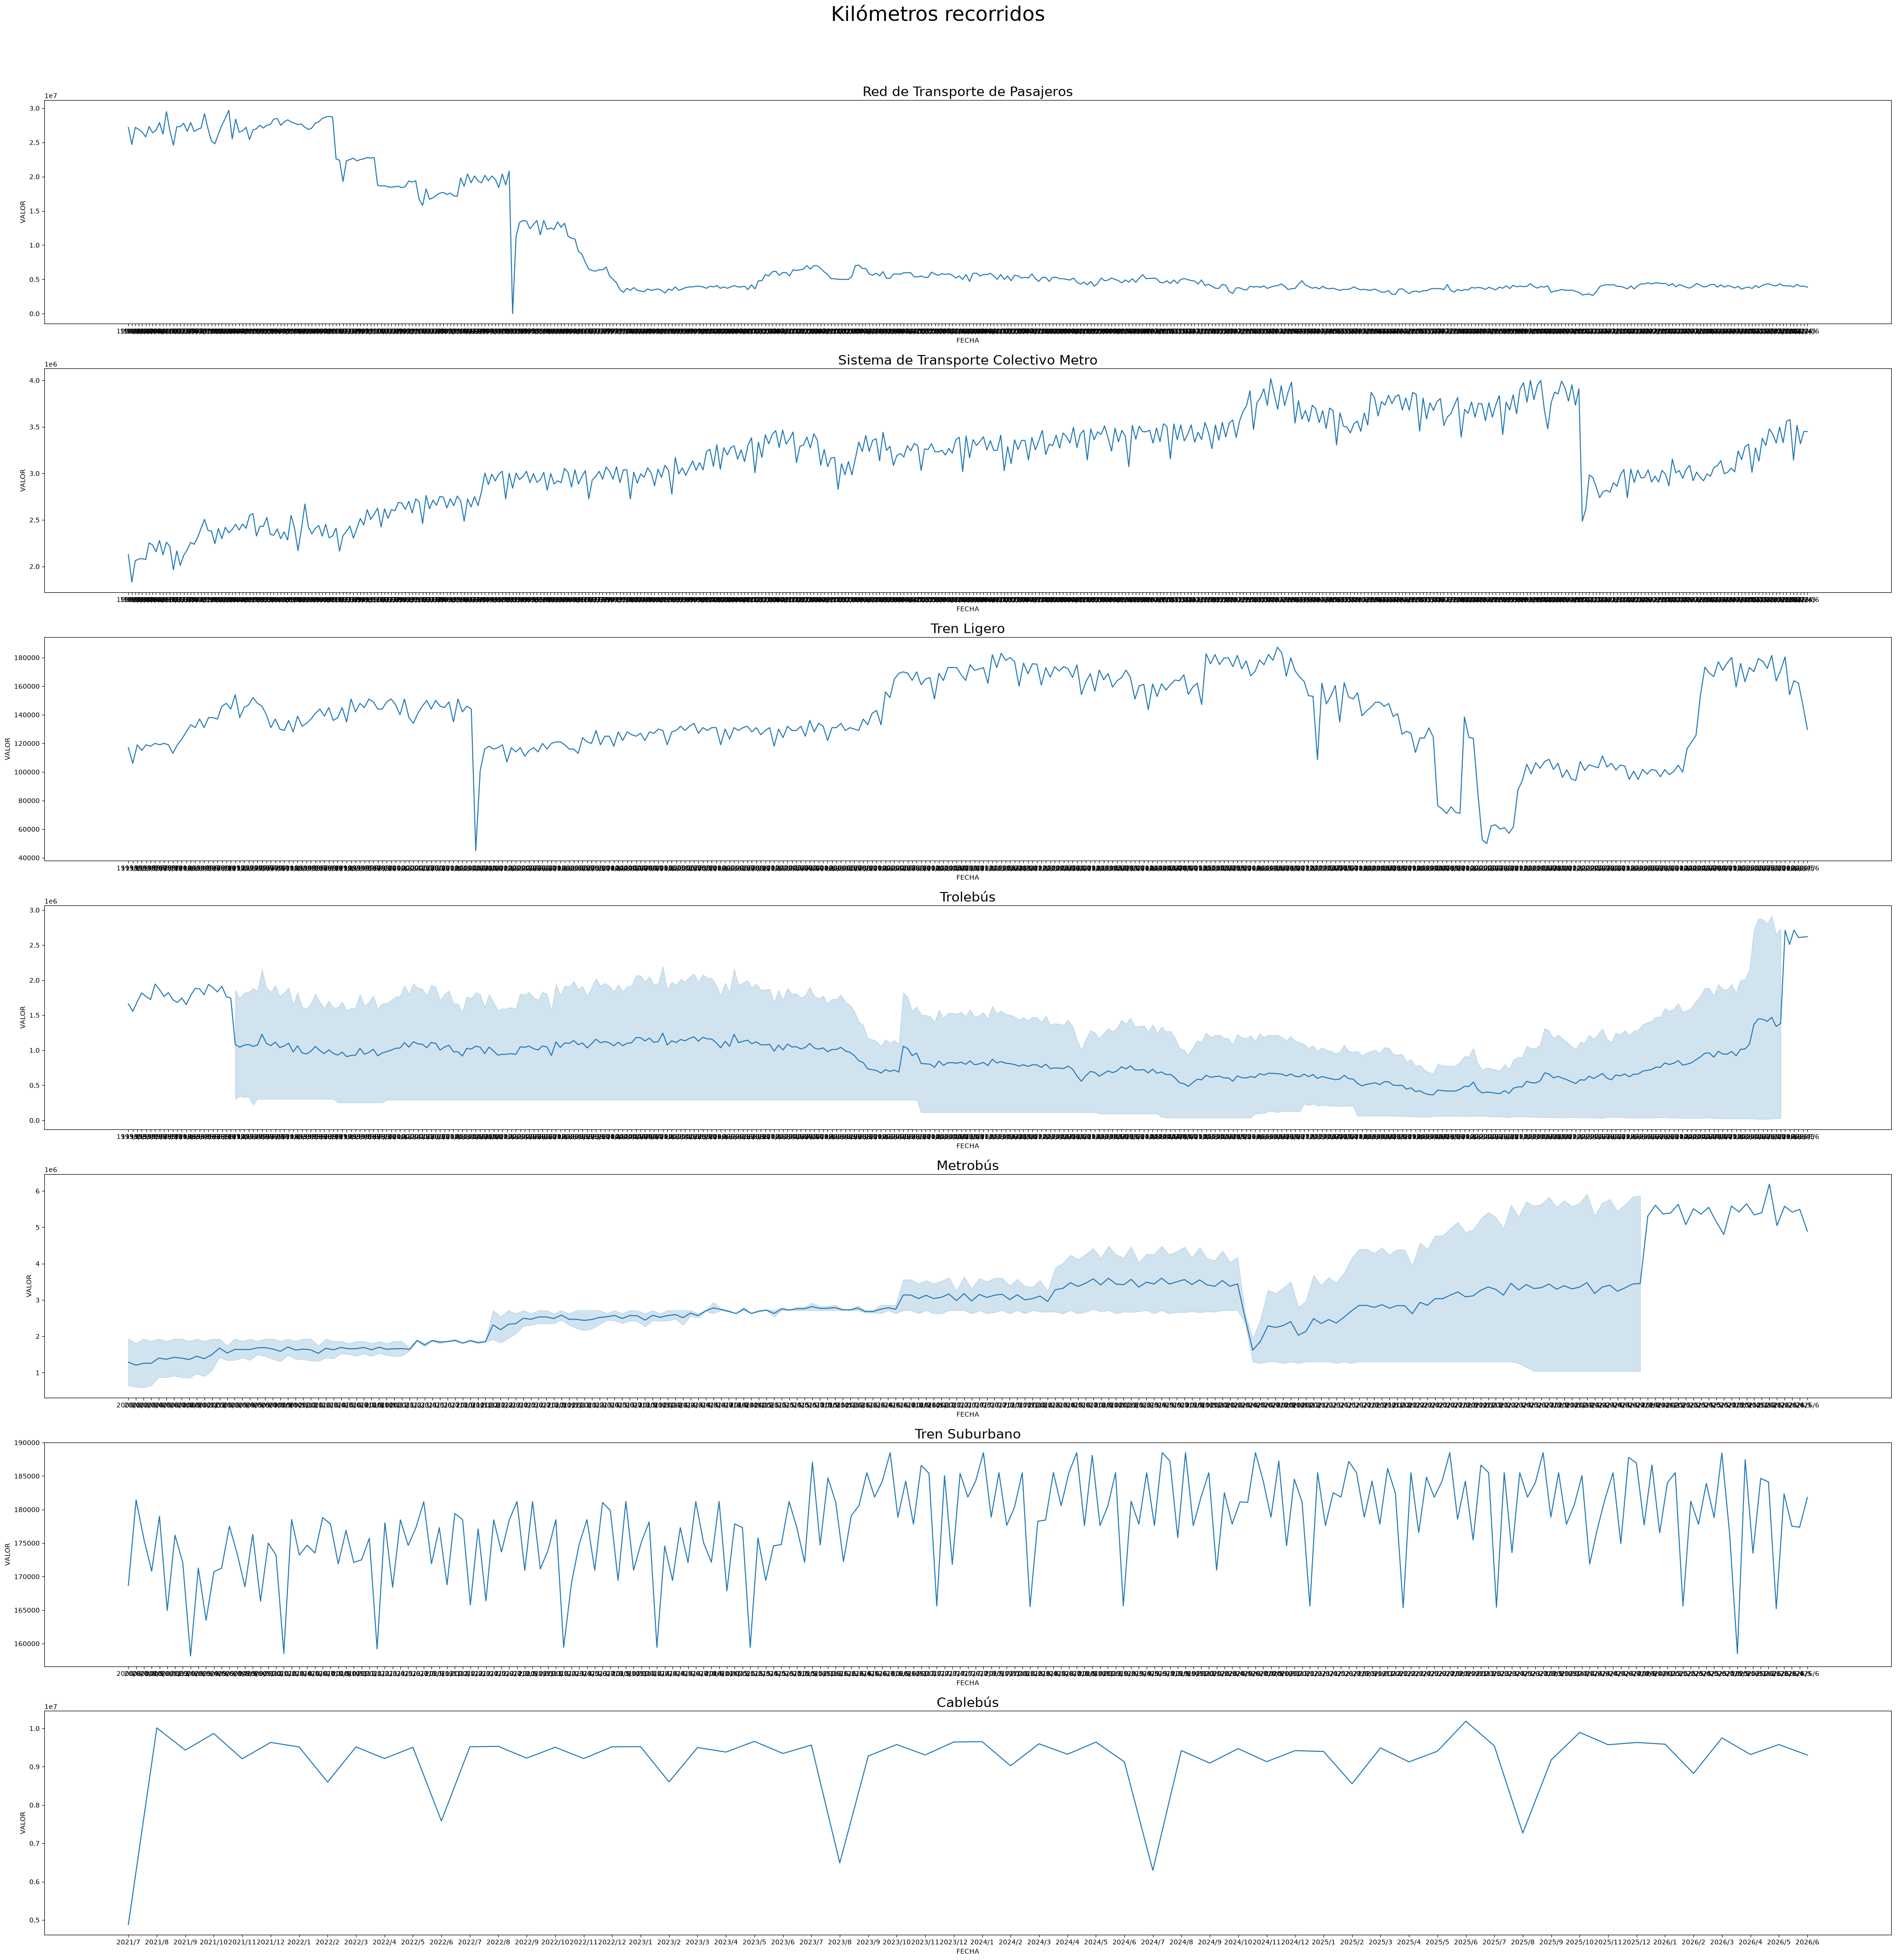

In [13]:
x=1
y=7
plt.figure(figsize=(50,50))

for i in range (num_plots2):
    plt.subplot(y,x,i+1)
    try:
        sns.lineplot(
            data=plots2[i],
            x='FECHA',
            y='VALOR',
        )
        plt.title((plots2[i]['TRANSPORTE'].unique()[0]), fontsize=20)
    except:
        print("List index out of range")
        

plt.suptitle(y_axis, y=0.92, fontsize=30)
plt.show()
#plt.close()

In [14]:
print(plots2[1])

        FECHA                             TRANSPORTE               VARIABLE  \
7      1986/1  Sistema de Transporte Colectivo Metro  Kilómetros recorridos   
18     1986/2  Sistema de Transporte Colectivo Metro  Kilómetros recorridos   
29     1986/3  Sistema de Transporte Colectivo Metro  Kilómetros recorridos   
40     1986/4  Sistema de Transporte Colectivo Metro  Kilómetros recorridos   
51     1986/5  Sistema de Transporte Colectivo Metro  Kilómetros recorridos   
...       ...                                    ...                    ...   
31916  2026/2  Sistema de Transporte Colectivo Metro  Kilómetros recorridos   
32101  2026/3  Sistema de Transporte Colectivo Metro  Kilómetros recorridos   
32278  2026/4  Sistema de Transporte Colectivo Metro  Kilómetros recorridos   
32455  2026/5  Sistema de Transporte Colectivo Metro  Kilómetros recorridos   
32632  2026/6  Sistema de Transporte Colectivo Metro  Kilómetros recorridos   

           VALOR  
7      2126600.0  
18     183120

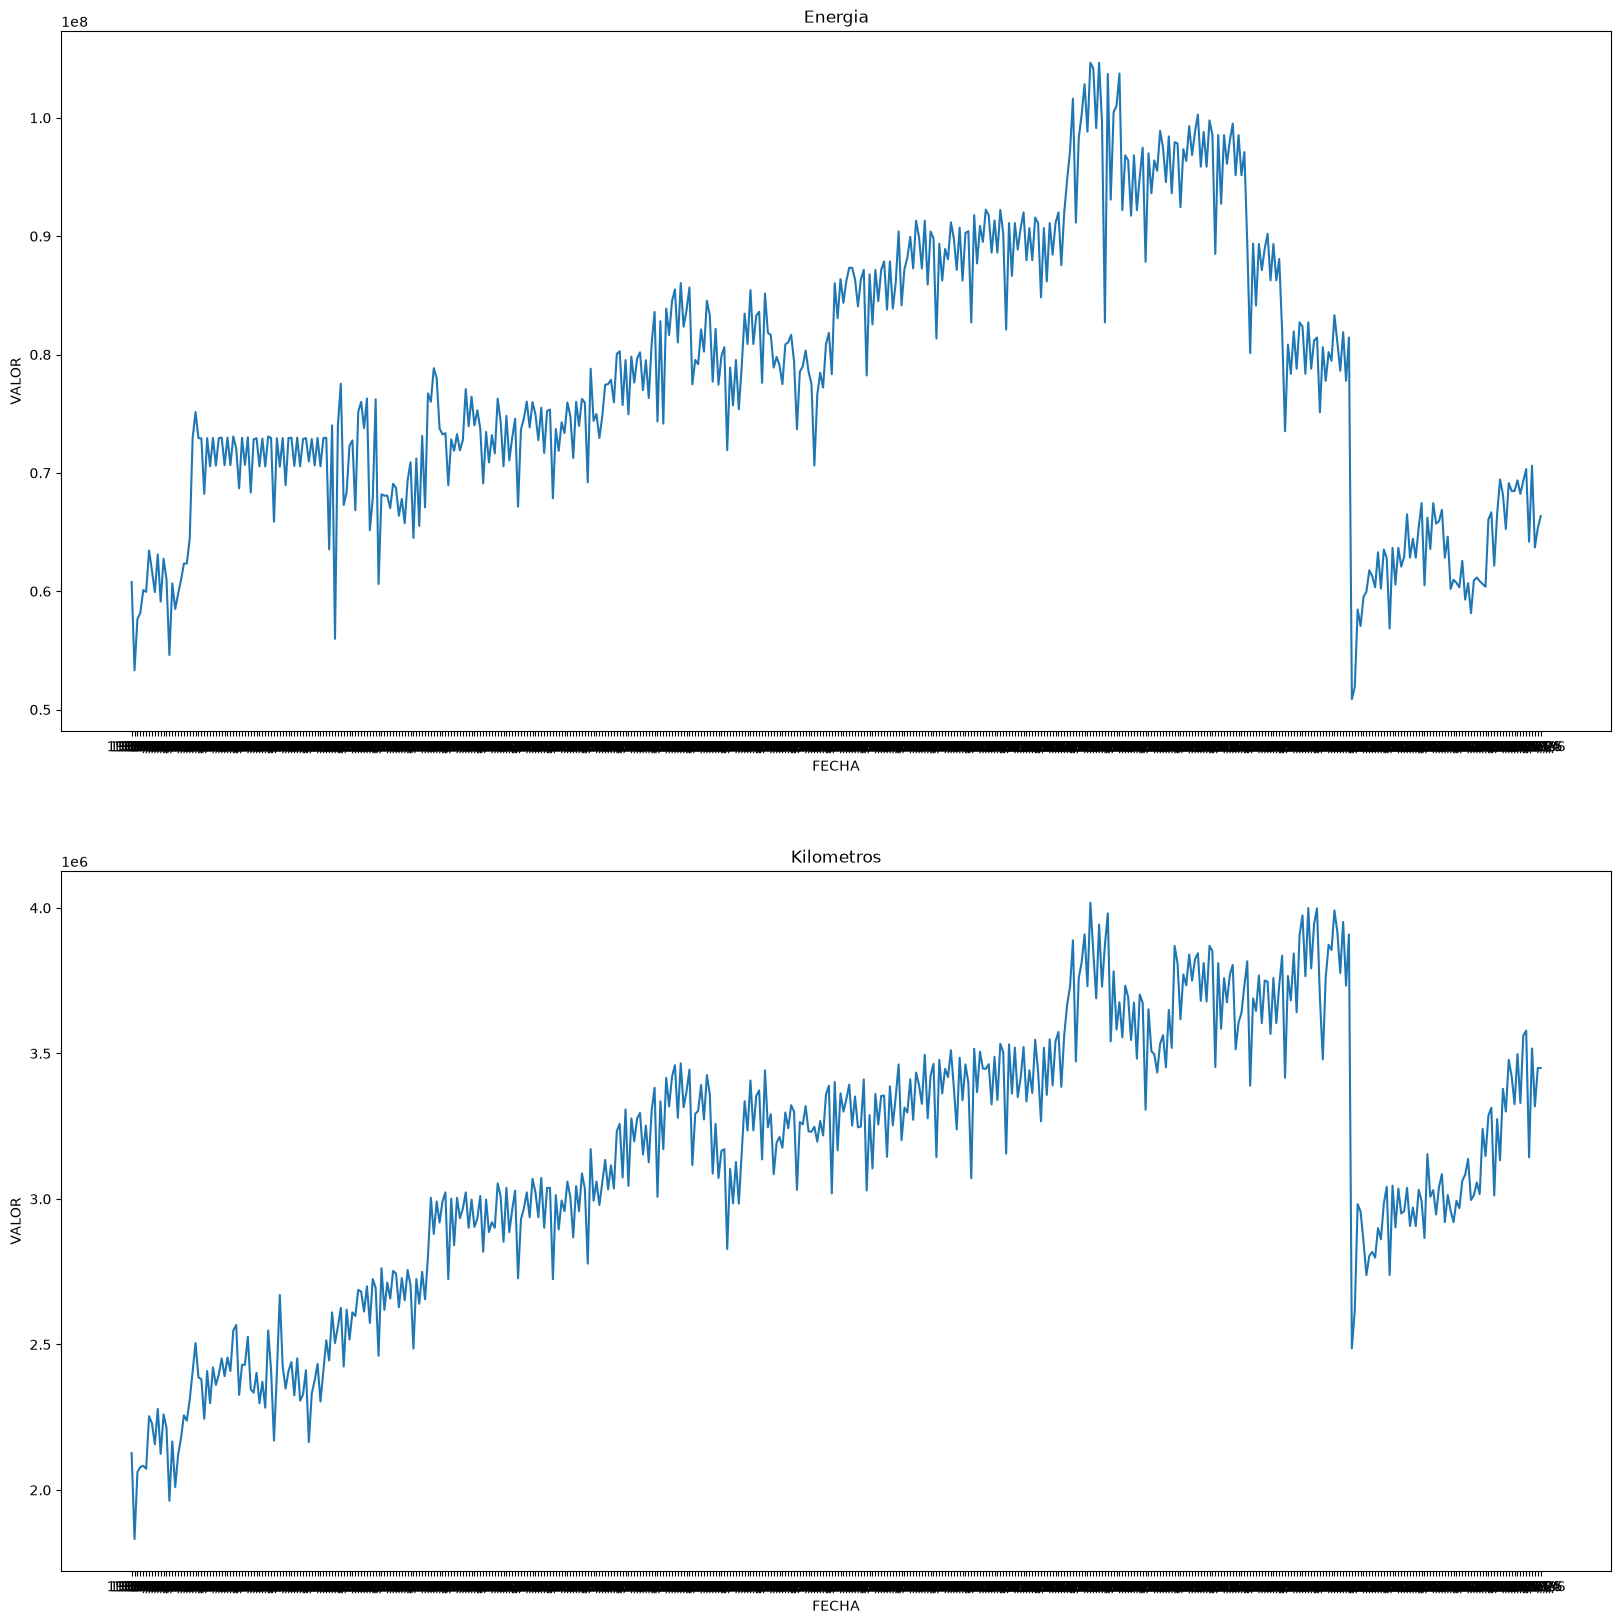

In [36]:
metro=df[df['TRANSPORTE']=='Sistema de Transporte Colectivo Metro']
metro_energia=metro[metro['VARIABLE']=='Energía eléctrica consumida']
metro_km=metro[metro['VARIABLE']=='Kilómetros recorridos']

metro_energia=metro_energia.reset_index(drop=True)
metro_km=metro_km.reset_index(drop=True)

plt.figure(figsize=(20,20))

plt.subplot(2,1,1)
sns.lineplot(
    data=metro_energia,
    x='FECHA',
    y='VALOR'
)
plt.title('Energia')

plt.subplot(2,1,2)
sns.lineplot(
    data=metro_km,
    x='FECHA',
    y='VALOR'
)
plt.title('Kilometros')

plt.show()

In [37]:
type(metro_km['VALOR'][0])

numpy.float64

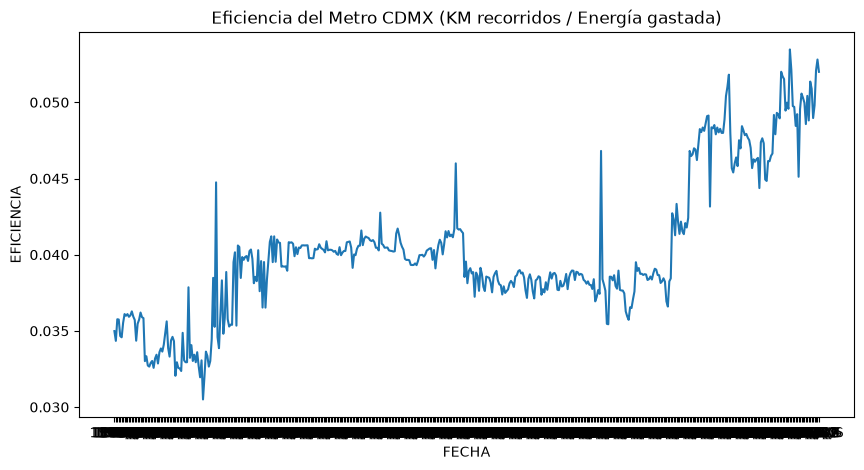

In [59]:
metro_km['EFICIENCIA']=metro_km['VALOR'].astype(float)/metro_energia['VALOR'].astype(float)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=metro_km,
    x='FECHA',
    y='EFICIENCIA'
)
plt.title('Eficiencia del Metro CDMX (KM recorridos / Energía gastada)')
plt.show()

In [60]:
print(metro_km)

     ANIO  ID_MES                             TRANSPORTE  \
0    1986       1  Sistema de Transporte Colectivo Metro   
1    1986       2  Sistema de Transporte Colectivo Metro   
2    1986       3  Sistema de Transporte Colectivo Metro   
3    1986       4  Sistema de Transporte Colectivo Metro   
4    1986       5  Sistema de Transporte Colectivo Metro   
..    ...     ...                                    ...   
481  2026       2  Sistema de Transporte Colectivo Metro   
482  2026       3  Sistema de Transporte Colectivo Metro   
483  2026       4  Sistema de Transporte Colectivo Metro   
484  2026       5  Sistema de Transporte Colectivo Metro   
485  2026       6  Sistema de Transporte Colectivo Metro   

                  VARIABLE  CVEGEO  CVE_ENT  CVE_MUN      VALOR  \
0    Kilómetros recorridos    9999        9      999  2126600.0   
1    Kilómetros recorridos    9999        9      999  1831200.0   
2    Kilómetros recorridos    9999        9      999  2061500.0   
3    Kilóme

In [85]:
print(
    df3[
        (df3['VARIABLE']=='Pasajeros transportados') &
        (df3['TRANSPORTE']=='Sistema de Transporte Colectivo Metro') &
        (df3['ANIO']>=2020) &
        (df3['ESTATUS']=='Cifras Definitivas')
    ].sum()['VALOR']
)


4993722239.0
